In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from package.flows.online.flow import get_online_flow, Shared
from uuid import uuid4
from broflow import state

d:\broai-arai\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Loading model from: BAAI/bge-m3


Fetching 30 files: 100%|██████████| 30/30 [00:00<?, ?it/s]


In [38]:
def generate_experiments(
    embed_methods=['raw'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
            "us.meta.llama3-2-11b-instruct-v1:0",
        ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
):
    from itertools import product
    
    is_terms = ['skip', 'evidence', 'explanation']
    is_contexts = [True, False]
    
    experiments = []
    for (embed_method, chat_prompt, term_prompt, chat_model, term_model, 
         is_term, is_context) in product(
        embed_methods, chat_system_prompt_paths, term_detector_system_prompt_paths,
        chat_models, term_detector_models, is_terms, is_contexts
    ):
        base_config = {
            "embed_method": embed_method,
            "chat_system_prompt_path": chat_prompt,
            "term_detector_system_prompt_path": term_prompt,
            "chat_model": chat_model,
            "term_detector_model": term_model,
            "is_term": is_term,
            "is_context": is_context
        }
        
        if is_context:
            experiments.extend([
                {**base_config, "is_rerank": False},
                {**base_config, "is_rerank": True}
            ])
        else:
            experiments.append({**base_config, "is_rerank": False})
    
    return experiments


In [39]:
from dataclasses import dataclass, asdict

@dataclass
class ControlExperiment:
    chat_model:str
    chat_system_prompt_path:str
    term_detector_model:str
    term_detector_system_prompt_path:str
    embed_method:str
    is_term:str
    is_context:bool
    is_rerank:bool
    experiment_set:str

In [40]:
experiments = generate_experiments(
    embed_methods=['raw', 'combo'],
    chat_system_prompt_paths=['./package/flows/online/prompts/v1/chat.md'],
    term_detector_system_prompt_paths=["./package/flows/online/prompts/term_detector.md"],
    chat_models=[
        "us.meta.llama3-2-1b-instruct-v1:0",
        "us.meta.llama3-2-11b-instruct-v1:0",
        "us.meta.llama4-maverick-17b-instruct-v1:0",
        "us.meta.llama4-scout-17b-instruct-v1:0",
        "meta.llama3-3-70b-instruct-v1:0",
        "us.meta.llama3-2-90b-instruct-v1:0",
    ],
    term_detector_models=["us.meta.llama3-2-11b-instruct-v1:0"]
)
len(experiments)

108

In [41]:
len(experiments)

108

In [42]:
import json

with open("./dataset/trainset.json", 'r', encoding='utf-8') as f:
    trainset = json.load(f)

In [43]:
for ts in trainset:
    ts['metadata']['source'] = ts['metadata']['source'].replace(":", "")

In [ ]:
def one_experiment(ts, con_exp:ControlExperiment):
    _id = str(uuid4())
    experiment_storage = "./evaluations/{file}.json".format(file=_id)
    shared = Shared(
        experiment_id=_id,
        experiment_set=con_exp.experiment_set,
        question=ts['question'],
        answer=ts['answer'],
        type=ts['type'],
        source=ts['metadata']['source'],
        chat_model=con_exp.chat_model,
        term_detector_model=con_exp.term_detector_model,
        chat_system_prompt_path=con_exp.chat_system_prompt_path,
        term_detector_system_prompt_path=con_exp.term_detector_system_prompt_path,
        experiment_storage=experiment_storage,
        embed_method=con_exp.embed_method,
        is_term=con_exp.is_term,
        is_context=con_exp.is_context,
        is_rerank=con_exp.is_rerank

    )

    flow = get_online_flow(experiment=shared.experiment_id)
    flow.run(shared)    

def main(trainset, experiments):
    for experiment in experiments:
        experiment.update({"experiment_set":str(uuid4())})
        con_exp = ControlExperiment(**experiment)
        for ts in trainset:
            one_experiment(ts, con_exp)

In [29]:
state.set('debug', False)
main(trainset[0:1], experiments[0:1])

Start bbc42273-a0ab-419f-84a1-538376eeb2a2


d:\broai-arai\backend\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


End bbc42273-a0ab-419f-84a1-538376eeb2a2


In [209]:
import json
import glob
import pandas as pd

def load_evaluations_to_dataframe(evaluations_dir="./experiments/evaluations"):
    data = []
    
    for file_path in glob.glob(f"{evaluations_dir}/*.json"):
        with open(file_path, 'r') as f:
            record = json.load(f)
        
        # Extract and flatten evaluation metrics
        if 'evaluation' in record:
            eval_data = record.pop('evaluation')
            for metric, values in eval_data.items():
                if isinstance(values, dict):
                    for sub_metric, value in values.items():
                        record[f"eval_{metric}_{sub_metric}"] = value
                else:
                    record[f"eval_{metric}"] = values
        
        data.append(record)
    
    return pd.DataFrame(data)


In [210]:
df = load_evaluations_to_dataframe()

In [217]:
def average_evaluation_metrics_by_experiment_set(df, grp_col=['experiment_set']):
    eval_columns = [col for col in df.columns if col.startswith('eval_')]
    numeric_eval_columns = df[eval_columns].select_dtypes(include=['number']).columns
    return df.groupby(grp_col)[numeric_eval_columns].mean().reset_index()

grp_col = [
    'experiment_set',
    'type',
    'chat_model',
    'is_term',
    'is_context',
    'is_rerank',
]
grp = average_evaluation_metrics_by_experiment_set(df, grp_col=grp_col)

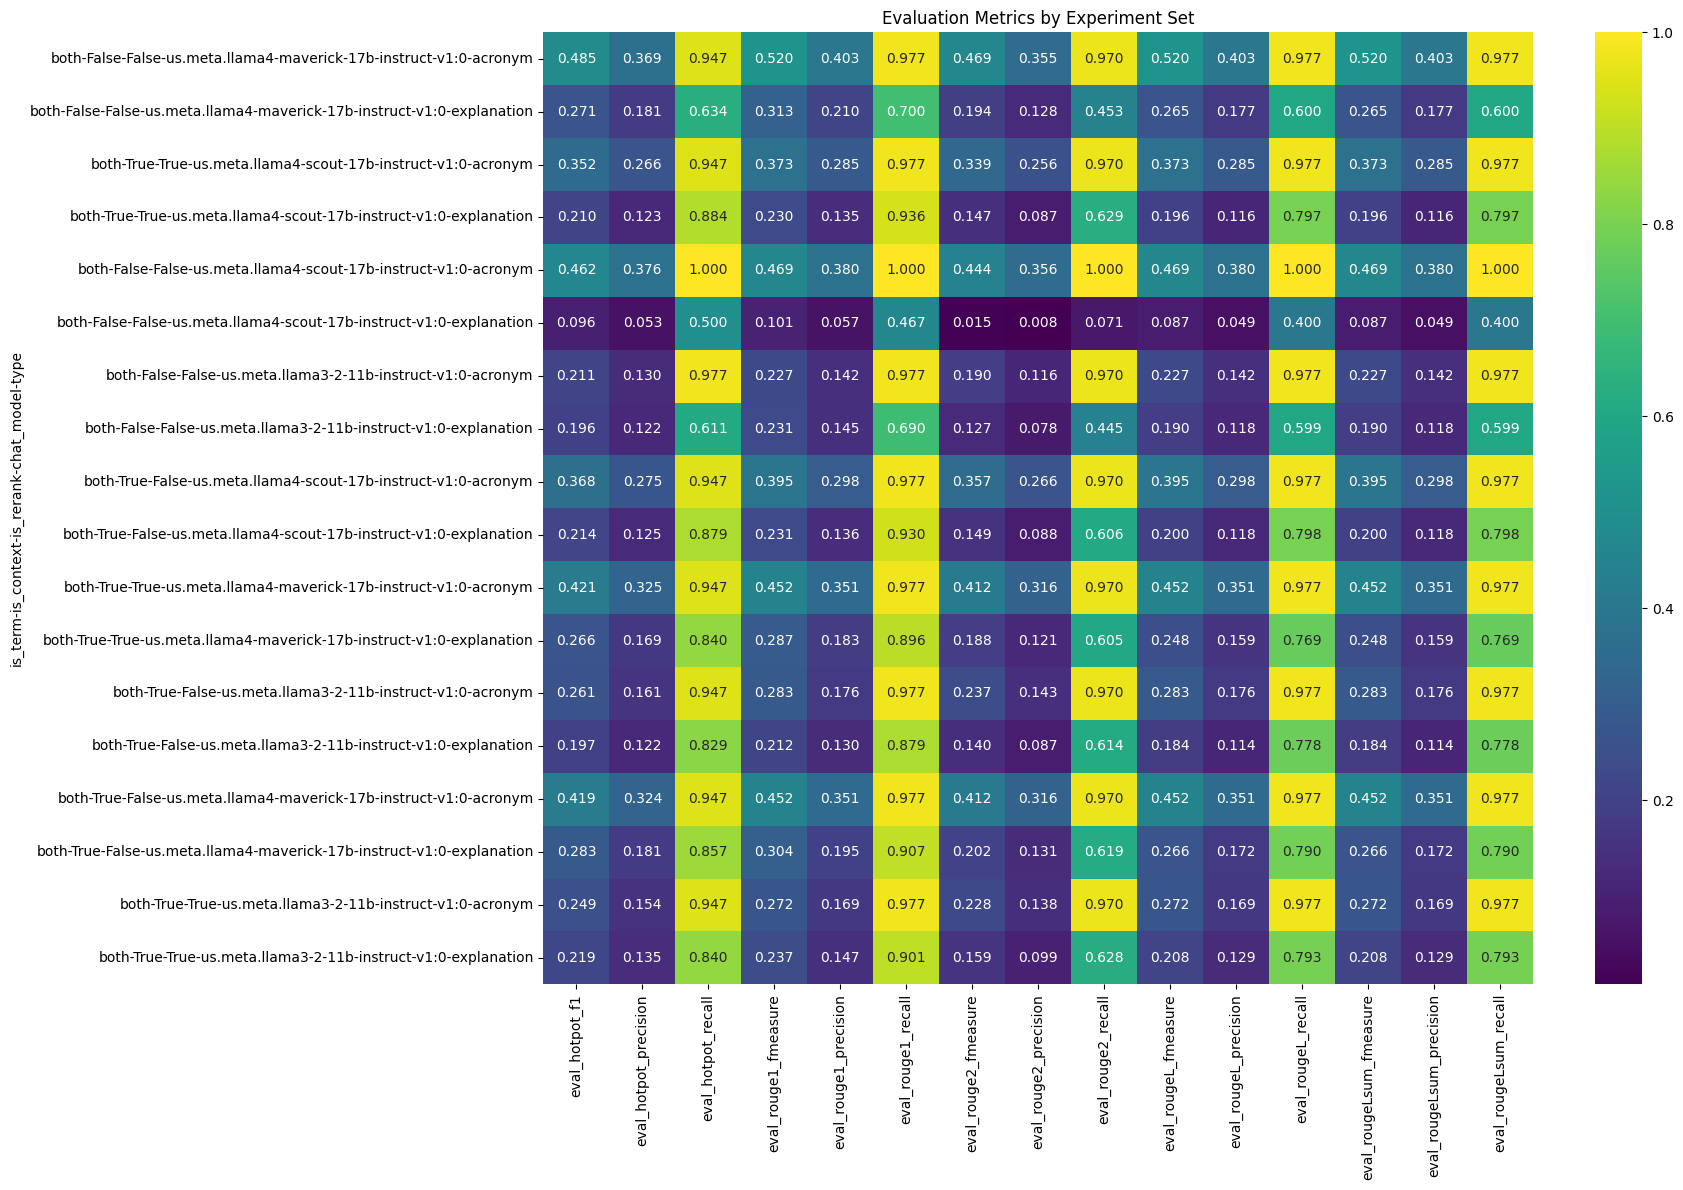

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_metrics(grp, set_index=['experiment_set'], suffixes=['_f1','_fmeasure', '_recall', '_precision']):
    eval_cols = [col for col in grp.columns if col.startswith('eval_') 
                 and any(col.endswith(suffix) for suffix in suffixes)]
    eval_cols = sorted(eval_cols)
    pivot_data = grp.set_index(set_index)[eval_cols]
    
    plt.figure(figsize=(18, 12))
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis')
    plt.title('Evaluation Metrics by Experiment Set')
    plt.tight_layout()
    plt.show()



# Quick ranking
def rank_experiments(grp, metric='eval_rouge1_fmeasure'):
    return grp.nlargest(10, metric)[['experiment_set', metric]]

# Usage examples:
visualize_metrics(grp, 
    # suffixes=[
    # # '_f1', 
    # # '_fmeasure',
    # # '_recall',
    # # '_precision',
    # ],
    set_index=[
        'is_term',
        'is_context',
        'is_rerank',
        'chat_model',
        'type',
    ]
)